<a href="https://colab.research.google.com/github/Tobi3333A/Brain-Tumor-Detection-System/blob/main/Brain_Tumor_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Based Dection of the Brain Tumor **

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!cd /content/drive/MyDrive/BrainTumorProject2

# # Load Dependencies, Load Modules, library, functions

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,confusion_matrix,roc_curve,auc
from sklearn import preprocessing
from warnings import filterwarnings
import os



In [18]:
####u can also use these modules/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Explanasion of Metrics- for accuracy of clissification
     

In [19]:
folder = "/content/drive/MyDrive/BrainTumorProject2"

In [20]:
import os
folder = os.listdir ('/content/drive/MyDrive/BrainTumorProject2')
print('folder')


folder


In [21]:
!ls

drive  sample_data


In [22]:
print(os.listdir('/content/drive/MyDrive/BrainTumorProject2'))  ######check the drive/folder/files

['brain_tumor']


#  Load, Prepare Dataset
I save dataset under brain_tumor folder (directory/folder)

In [23]:
current_dir = os.listdir('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Training')

print(current_dir)

['pituitary_tumor', 'no_tumor']


In [24]:
parent_directory = "/content/drive/MyDrive/BrainTumorProject2"  # Replace with your actual path
subdirectory_name = "brain_tumor/Training"
#file_name = "my_file.txt"

In [25]:
#Data_Train = os.listdir(parent_directory + '/brain_tumor/Training/')
classes = {'no_tumor':0, 'pituitary_tumor':1}

In [26]:
import cv2
X = []
Y = []
for clss in classes:
    #pth = os.path.join(parent_directory, 'brain_tumor', 'Training', cls)
    pth = os.path.join(parent_directory, subdirectory_name, clss)
    for j in os.listdir(pth):
        img_path = os.path.join(pth, j)
        img = cv2.imread(img_path, 0)
        if img is None:
            print(f"Warning: Could not load image at path: {img_path}. Skipping this file.")
            continue
        img = cv2.resize(img, (200,200))
        X.append(img)
        Y.append(classes[clss])

In [27]:
X = np.array(X)
Y = np.array(Y)

In [28]:
np.unique(Y)

array([0, 1])

In [29]:
Y.shape, X.shape

((1222,), (1222, 200, 200))

In [30]:
pd.Series(Y).value_counts()

,count
1,827
0,395


# Visualize Data sets/(images)

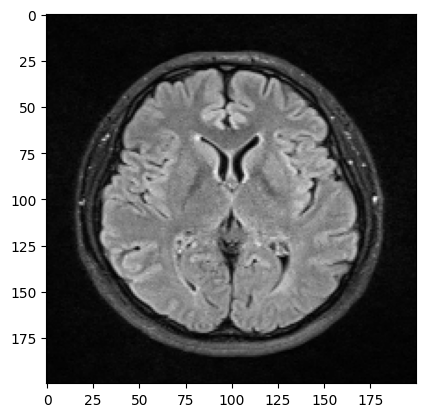

In [31]:
plt.imshow(X[0], cmap='gray')

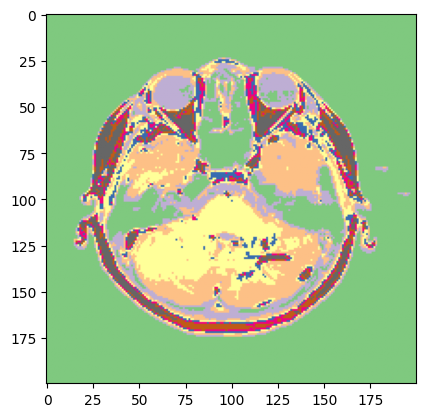

In [32]:
plt.imshow(X[45], cmap='Accent')

Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'crest', 'crest_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'flare', 'flare_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'g...

# Prepare dataset

In [33]:
X_s = X.reshape(len(X), -1)
X_s.shape

(1222, 40000)

# Split dataset Train and test

In [34]:
xtrain, xtest, ytrain, ytest = train_test_split(X_s, Y, random_state=10,
                                               test_size=.20)

In [35]:
xtrain.shape, xtest.shape

((977, 40000), (245, 40000))

# Scaling dataset-(features)

In [36]:
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())


255 0
255 0


In [37]:
xtrain = xtrain/255
xtest = xtest/255
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())

1.0 0.0
1.0 0.0


# Feature Selection: PCA (principle component analysis)

In [38]:
#########import statistical model from sklearn library
from sklearn.decomposition import PCA


In [39]:
#####pca with standardscale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(xtrain) # X represents your feature matrix

In [40]:
pca = PCA(.98) # Set to None to keep all components initially default: pca = PCA()
# pca.fit(X_scaled)

In [41]:
pca_trains = pca.fit_transform(X_scaled)
pca_tests = pca.transform(xtest)
# pca_train = xtrain
# pca_test = xtest

In [42]:
print(pca_trains.shape, pca_tests.shape)

# print(pca.n_components_)
# print(pca.n_features_in_)

(977, 612) (245, 612)


In [43]:
print(pca.n_components_)
print(pca.n_features_in_)

612
40000


In [44]:
print("Number of components:", pca_trains.shape[1])
print("Number of original features:", xtrain.shape[1])

Number of components: 612
Number of original features: 40000


In [45]:
print(pca_trains.shape, pca_tests.shape)

# print(pca.n_components_in)
# print(pca.n_features_in_)

(977, 612) (245, 612)


In [46]:
print(pca_trains.shape, pca_trains.shape)

print(xtrain.shape[1])

(977, 612) (977, 612)
40000


In [47]:

# If you want, you can also print variance info:

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[1.66220845e-01 9.29377779e-02 3.84317015e-02 2.86711816e-02
 2.55301085e-02 1.89448558e-02 1.71555214e-02 1.42804954e-02
 1.22556269e-02 1.20094972e-02 1.05834069e-02 1.04796779e-02
 9.48030366e-03 9.22398812e-03 8.93027886e-03 8.62404836e-03
 8.16821621e-03 7.42123365e-03 7.26213945e-03 6.96627611e-03
 6.93112750e-03 6.45802087e-03 6.40701486e-03 6.06403421e-03
 5.78061262e-03 5.73821897e-03 5.47733938e-03 5.30998751e-03
 5.28590765e-03 4.91699421e-03 4.86127779e-03 4.72905810e-03
 4.63111094e-03 4.49333275e-03 4.23221549e-03 4.18146056e-03
 4.14291936e-03 3.99822127e-03 3.96606352e-03 3.84877700e-03
 3.71622542e-03 3.69664263e-03 3.59666262e-03 3.55103590e-03
 3.43133946e-03 3.39572782e-03 3.35863738e-03 3.31206907e-03
 3.29733582e-03 3.21097162e-03 3.11404667e-03 3.09460712e-03
 3.06263346e-03 2.91816420e-03 2.86301713e-03 2.84133399e-03
 2.78959115e-03 2.73825289e-03 2.66842928e-03 2.66175512e-03
 2.59794207e-03 2.56426588e-03 2.53791531e-03 2.48373396e-03
 2.47690526e-03 2.443401

# Train Model

In [48]:
#import model from sklear
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [49]:
import warnings
warnings.filterwarnings('ignore')

# lg = LogisticRegression(C=0.1)
# lg.fit(pca_train, ytrain)


In [50]:
lg = LogisticRegression(C=0.1)
lg.fit(pca_trains, ytrain)

LogisticRegression(C=0.1)

In [51]:
sv = SVC()
sv.fit(xtrain, ytrain)

SVC()

# EVALUATION

In [53]:
print("Training Score:", sv.score(xtrain, ytrain))
print("Testing Score:", sv.score(xtest, ytest))

Training Score: 0.9928352098259979
Testing Score: 0.9673469387755103


# PREDICTION

In [57]:
predv = sv.predict(xtest)

In [58]:
misclassified=np.where(ytest!=predv)
misclassified

(array([ 35,  52, 117, 140, 158, 160, 236, 237]),)

In [59]:
print("Total Misclassified Samples: ",len(misclassified[0]))
print(predv[36],ytest[36])

Total Misclassified Samples:  8
1 1


#TESTING MODEL

In [60]:
dec = {0:'No Tumor', 1:'Positive Tumor'}

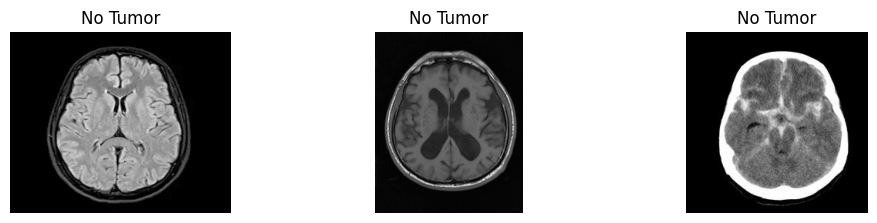

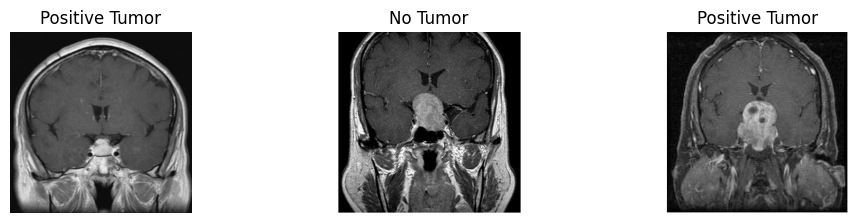

In [61]:
plt.figure(figsize=(12,8))
p = os.listdir('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Testing/')
c=1
for i in os.listdir('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Testing/no_tumor/')[:3]:
    plt.subplot(3,3,c)

    img = cv2.imread('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Testing/no_tumor/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = sv.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
plt.figure(figsize=(12,8))
p = os.listdir('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Testing/')
c=1
for i in os.listdir('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Testing/pituitary_tumor/')[:3]:
    plt.subplot(3,3,c)

    img = cv2.imread('/content/drive/MyDrive/BrainTumorProject2/brain_tumor/Testing/pituitary_tumor/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = sv.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1